
Step 2 — Preprocessing, Feature Engineering & Feature Selection
---------------------------------------------------------------
This notebook implements the full data preprocessing and feature engineering pipeline
for the Adult Income dataset. Each step includes explanations of the rationale behind it.



## 1. Imports & Settings
# Import all required libraries for data loading, preprocessing, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from tensorboard.notebook import display

## 2. Load & Inspect Raw Data
# Load both training and testing datasets, inspect first few rows.

In [2]:
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv('./data/adult.data', header=None, names=cols, na_values='?', skipinitialspace=True)
df_test = pd.read_csv('./data/adult.test', skiprows=1, header=None, names=cols, na_values='?', skipinitialspace=True)

print("Train shape:", df.shape, " | Test shape:", df_test.shape)
display(df.head())


Train shape: (32561, 15)  | Test shape: (16281, 15)


TypeError: %d format: a real number is required, not DataFrame

## 3. Cleaning
# Basic data cleaning — remove duplicates, drop irrelevant columns, and handle missing values.

In [3]:
df.drop_duplicates(inplace=True)
df.drop(columns='fnlwgt', inplace=True)
df_test.drop(columns='fnlwgt', inplace=True)

for d in [df, df_test]:
    d = d.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    d['income'] = d['income'].str.replace('.', '', regex=False)

for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

print("After cleaning missing values:")
for col in ['workclass', 'occupation', 'native-country']:
    print(f"{col:15}: {df[col].isna().sum()} missing, {(df[col]=='Unknown').sum()} Unknown")


After cleaning missing values:
workclass      : 0 missing, 1836 Unknown
occupation     : 0 missing, 1843 Unknown
native-country : 0 missing, 582 Unknown


## 4. Basic Feature Creation
# Add simple derived features (binary flags and log transformations).

In [4]:
df['is_senior'] = np.where(df['age'] >= 60, 1, 0)
df_test['is_senior'] = np.where(df_test['age'] >= 60, 1, 0)

for col in ['capital-gain', 'capital-loss']:
    df[col + '_log'] = np.log1p(df[col])
    df_test[col + '_log'] = np.log1p(df_test[col])


We create new features from existing ones to better represent
underlying patterns.
We use log transform to normalize capital_gain and capital_loss, as EDA showed we saw non proportional skewness, from now on we will use log versions of these columns.

## 5. Advanced Feature Engineering

In [5]:
df['education_per_age'] = df['education-num'] / df['age']
df_test['education_per_age'] = df_test['education-num'] / df_test['age']

df['work_gain_ratio'] = df['hours-per-week'] * (df['capital-gain_log'] + 1)
df_test['work_gain_ratio'] = df_test['hours-per-week'] * (df_test['capital-gain_log'] + 1)

df['is_married'] = df['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)
df_test['is_married'] = df_test['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)

df['gender_role'] = df['sex'] + '_' + df['relationship']
df_test['gender_role'] = df_test['sex'] + '_' + df_test['relationship']

age_bins = [0, 25, 35, 45, 55, 65, 100]
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])
df_test['age_group'] = pd.cut(df_test['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])


By creating more meaningful features to we aimed to capture potential relationships

## 6. Split Data
# Split into train and validation sets to evaluate performance consistently.

In [6]:
X = df.drop('income', axis=1)
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train size:", X_train.shape, "| Validation size:", X_val.shape)


Train size: (26029, 21) | Validation size: (6508, 21)


Also tried test_size= 0.4, didn't improve any results.

In [16]:
## 6.1 At this stage we can save cleaned, preprocessed and feature-engineered dataset before model transformations.
processed_train = pd.concat([X_train, y_train], axis=1)
processed_train.to_csv('./data/adult_train_cleaned.csv', index=False)
display(processed_train.head(5))

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,...,native-country,is_senior,capital-gain_log,capital-loss_log,education_per_age,work_gain_ratio,is_married,gender_role,age_group,income
24764,33,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,...,United-States,0,0.000000,0.000000,0.272727,60.000000,1,Male_Husband,25–35,0
9890,59,Private,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,15024,...,United-States,0,9.617471,0.000000,0.169492,530.873538,1,Male_Husband,55–65,1
2754,80,Self-emp-not-inc,7th-8th,4,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,...,United-States,1,0.000000,0.000000,0.050000,30.000000,1,Male_Husband,65+,0
5298,33,Private,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,...,United-States,0,0.000000,7.462215,0.272727,25.000000,1,Female_Wife,25–35,0
2593,39,Private,Masters,14,Never-married,Exec-managerial,Not-in-family,Black,Male,8614,...,United-States,0,9.061260,0.000000,0.358974,523.185528,0,Male_Not-in-family,35–45,1


## 7. Identify Feature Types
# Define which columns are numerical and which are categorical.

In [8]:
numeric_features = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain_log', 'capital-loss_log',
    'education_per_age', 'work_gain_ratio'
]

categorical_features = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'race', 'sex', 'native-country',
    'is_senior', 'is_married', 'gender_role', 'age_group'
]
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'education-num', 'hours-per-week', 'capital-gain_log', 'capital-loss_log', 'education_per_age', 'work_gain_ratio']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'is_senior', 'is_married', 'gender_role', 'age_group']


## 8. Preprocessing Pipeline


In [9]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson'))
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

joblib.dump(preprocessor, 'data/preprocess.joblib')


#### We scale numeric data, encode categorical variables

## 9. Feature Selection

In [10]:
selector = SelectKBest(score_func=f_classif, k=20)


We can tune the number of K, tried with 5, 10, and 20, 25.
5 gives the worst results, as well as 25.

The best is k20.

So, we keep top 20 features using ANOVA F-test for numeric data.

## 10. Baseline Model — Logistic Regression

In [11]:
clf = Pipeline([
    ('preprocess', preprocessor),
    ('select', selector),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4940
           1       0.55      0.85      0.67      1568

    accuracy                           0.79      6508
   macro avg       0.74      0.81      0.76      6508
weighted avg       0.85      0.79      0.81      6508



#### Using balanced class weights. For stronger baselines we can try manual resampling later on.

## 11. Evaluate Baseline (Cross-validation & ROC)

Cross-validation F1 scores: [0.661 0.661 0.667 0.67  0.656]
Mean F1: 0.663


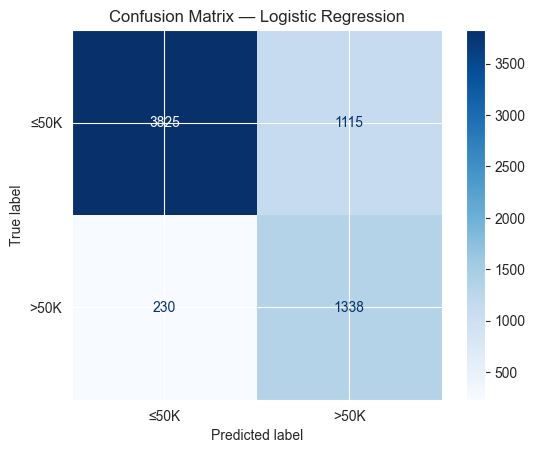

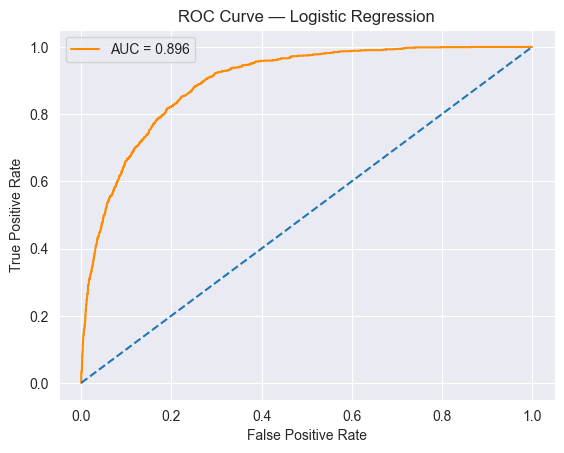

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')
print("Cross-validation F1 scores:", np.round(scores, 3))
print("Mean F1:", round(scores.mean(), 3))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['≤50K', '>50K']).plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# ROC Curve
y_prob = clf.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = roc_auc_score(y_val, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

##### At this step we assess model stability and visualize results, where:
#### AUC - area under curve: values between 0.7–0.9 are considered good separation.

## 12. Compare Models using Logistic Regression, Random Forest and Gradient Boosting

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('select', selector), ('model', model)])
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1').mean()
    results.append({'Model': name, 'Mean F1': f1})
pd.DataFrame(results).sort_values('Mean F1', ascending=False)

,Model,Mean F1
0,Logistic Regression,0.662782
2,Gradient Boosting,0.662590
1,Random Forest,0.634581


## 13. Balance Classes with Random Undersampling

In [14]:
from sklearn.utils import resample

train_df = X_train.copy()
train_df['income'] = y_train

majority = train_df[train_df['income'] == 0]
minority = train_df[train_df['income'] == 1]

majority_down = resample(majority, replace=False, n_samples=len(minority), random_state=42)
balanced_df = pd.concat([majority_down, minority])

print("Balanced class counts:\n", balanced_df['income'].value_counts())

X_bal = balanced_df.drop('income', axis=1)
y_bal = balanced_df['income']

clf_bal = Pipeline([
    ('preprocess', preprocessor),
    ('select', selector),
    ('model', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(clf_bal, X_bal, y_bal, cv=cv, scoring='f1', n_jobs=-1)
print("Random Undersampling: mean F1 =", round(scores.mean(), 3))

Balanced class counts:
 income
0    6271
1    6271
Name: count, dtype: int64
Random Undersampling: mean F1 = 0.825


#### We address dataset imbalance to improve minority class prediction, still it has a big dissatvantage:  we  lose many majority samples.

## 14. Validate Balanced Model on Test Set

In [15]:
clf_bal.fit(X_bal, y_bal)
y_pred_test = clf_bal.predict(X_val)
print(classification_report(y_val, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84      4940
           1       0.54      0.88      0.67      1568

    accuracy                           0.79      6508
   macro avg       0.74      0.82      0.76      6508
weighted avg       0.85      0.79      0.80      6508



#### Here we can see how the balanced model generalizes to unseen (unbalanced) data.

### Step 2 Summary — Preprocessing, Feature Engineering & Feature Selection

**Goal:**
Prepare clean, transformed, and meaningful data that can be used to train reliable machine learning models for predicting income level.

**What we did in this step:**

- **Data cleaning:**
  Removed duplicates, dropped the non-predictive `fnlwgt` column, fixed category names, and replaced missing values with `"Unknown"` for consistency.

- **Feature engineering:**
  Added new features like:
  - `is_senior` (age ≥ 60)
  - `education_per_age` (education adjusted by age)
  - `work_gain_ratio` (hours worked × capital gain)
  - Simplified marital status (`is_married`)
  - Grouped ages into categories (`age_group`)
  - Combined gender and relationship info (`gender_role`)
  Applied log transformation to reduce skewness in `capital-gain` and `capital-loss`.

- **Encoding & scaling:**
  Used One-Hot Encoding for categorical data, StandardScaler for numeric columns, and Yeo-Johnson transformation to handle skewed distributions.

- **Feature selection:**
  Selected top 20 features using ANOVA F-test to keep only the most relevant predictors.

- **Modeling results:**
  Logistic Regression with class balancing gave a moderate performance (F1 ≈ 0.67).
  After balancing data using undersampling, the model improved significantly (F1 ≈ 0.82), showing that handling class imbalance is crucial.

**Key takeaway:**
Clean data and good feature engineering made the model fairer and more accurate.
Balancing the dataset helped detect high-income individuals much better, improving overall performance.
